# Iniciación en análisis de datos con Python

**Mayo 2026 · Bloque I**

## Objetivos
- Configurar el entorno de trabajo en Jupyter/VS Code
- Cargar, explorar y limpiar datos con pandas
- Construir un análisis descriptivo reproducible

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga de datos y primera inspección

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

df = pd.read_csv(DATA_DIR / "ventas_mayo2026.csv", parse_dates=["fecha"])
display(df.head())
df.info()

,fecha,region,canal,clientes,visitas,inversion_marketing,ventas
0,2025-01-01,Este,partner,40,700,795.33,2294.40
1,2025-01-02,Oeste,web,39,663,975.02,1291.86
2,2025-01-03,Sur,partner,33,691,445.83,1303.57
3,2025-01-04,Oeste,web,37,707,801.57,2308.37
4,2025-01-05,Oeste,web,31,703,686.07,2026.70


<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   fecha                180 non-null    datetime64[us]
 1   region               180 non-null    str           
 2   canal                174 non-null    str           
 3   clientes             180 non-null    int64         
 4   visitas              180 non-null    int64         
 5   inversion_marketing  180 non-null    float64       
 6   ventas               172 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 10.0 KB


## Limpieza básica y tipos de datos

In [2]:
df_clean = df.copy()
df_clean["canal"] = df_clean["canal"].fillna("desconocido")
df_clean["ventas"] = df_clean["ventas"].fillna(df_clean["ventas"].median())
df_clean["conversion"] = df_clean["clientes"] / df_clean["visitas"]
display(df_clean.describe(include="all"))

,fecha,region,canal,clientes,visitas,inversion_marketing,ventas,conversion
count,180,180,180,180.000000,180.000000,180.000000,180.000000,180.000000
unique,NaN,5,4,NaN,NaN,NaN,NaN,NaN
top,NaN,Este,web,NaN,NaN,NaN,NaN,NaN
freq,NaN,45,89,NaN,NaN,NaN,NaN,NaN
mean,2025-03-31 12:00:00,NaN,NaN,40.294444,699.550000,590.372889,1889.721444,0.057673
min,2025-01-01 00:00:00,NaN,NaN,26.000000,641.000000,167.450000,938.780000,0.036313
25%,2025-02-14 18:00:00,NaN,NaN,36.000000,684.000000,421.817500,1621.290000,0.052340
50%,2025-03-31 12:00:00,NaN,NaN,41.000000,701.000000,570.485000,1868.090000,0.058443
75%,2025-05-15 06:00:00,NaN,NaN,44.000000,716.000000,740.295000,2119.340000,0.062970
max,2025-06-29 00:00:00,NaN,NaN,57.000000,766.000000,1466.090000,3075.070000,0.081545


## Agrupaciones y visualización

,region,canal,ventas_totales,clientes,conversion_media
15,Oeste,web,40189.10,803,0.057340
19,Sur,web,36971.43,766,0.057724
7,Este,web,35459.56,742,0.056441
3,Centro,web,33079.95,709,0.059782
11,Norte,web,25702.66,538,0.054952
5,Este,partner,23975.91,539,0.055085
6,Este,tienda,21080.39,467,0.061276
2,Centro,tienda,20851.87,434,0.056484
1,Centro,partner,18315.99,385,0.060983
10,Norte,tienda,16345.78,396,0.056394


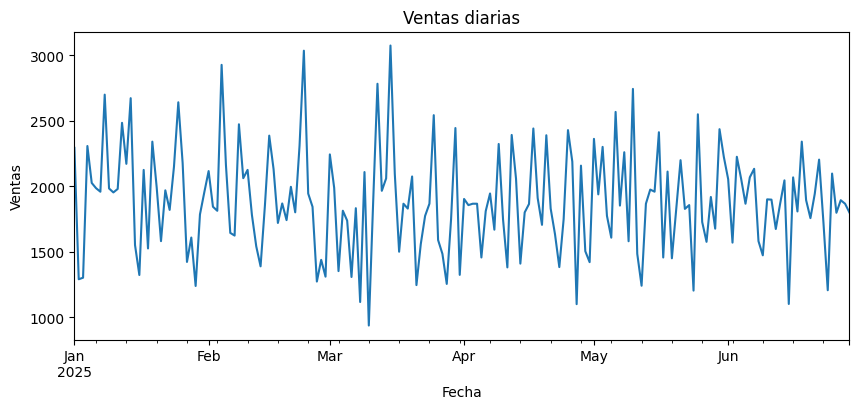

In [3]:
resumen = df_clean.groupby(["region","canal"], as_index=False).agg(
    ventas_totales=("ventas","sum"),
    clientes=("clientes","sum"),
    conversion_media=("conversion","mean")
).sort_values("ventas_totales", ascending=False)
display(resumen.head(10))

ventas_dia = df_clean.groupby("fecha")["ventas"].sum()
ventas_dia.plot(figsize=(10,4), title="Ventas diarias")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.show()

## Mini-reto

In [4]:
# Reto: identifica el canal con mejor conversión media y argumenta si coincide con mayor volumen de ventas.
display(df_clean.groupby("canal").agg(ventas=("ventas","sum"), conversion=("conversion","mean")).sort_values("conversion", ascending=False))

,ventas,conversion
canal,,
desconocido,11834.73,0.058592
tienda,85044.94,0.058399
partner,71867.49,0.057478
web,171402.70,0.057321


## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.

In [6]:
# Resolución del mini-reto: Canal con mejor conversión media y comparación con volumen de ventas
resumen_canales = df_clean.groupby("canal").agg(ventas=("ventas","sum"), conversion=("conversion","mean")).sort_values("conversion", ascending=False)

canal_mejor_conversion = resumen_canales.index[0]
conversion_mejor = resumen_canales.loc[canal_mejor_conversion, "conversion"]

canal_mayor_ventas = df_clean.groupby("canal")["ventas"].sum().idxmax()
ventas_mayor = df_clean.groupby("canal")["ventas"].sum().max()

print(f"Canal con mejor conversión media: {canal_mejor_conversion} (conversión: {conversion_mejor:.2%})")
print(f"Canal con mayor volumen de ventas: {canal_mayor_ventas} (ventas: {ventas_mayor:.2f})")

if canal_mejor_conversion == canal_mayor_ventas:
    print("Coinciden: El canal con mejor conversión también tiene el mayor volumen de ventas.")
else:
    print("No coinciden: La mejor conversión no implica el mayor volumen de ventas. Un canal puede ser eficiente (alta conversión) sin generar tanto volumen, o viceversa.")

Canal con mejor conversión media: desconocido (conversión: 5.86%)
Canal con mayor volumen de ventas: web (ventas: 171402.70)
No coinciden: La mejor conversión no implica el mayor volumen de ventas. Un canal puede ser eficiente (alta conversión) sin generar tanto volumen, o viceversa.


## Interpretación de resultados
El canal "desconocido" muestra la mejor conversión media (5.86%), indicando eficiencia en convertir visitas en clientes. Sin embargo, no coincide con el mayor volumen de ventas, que pertenece al canal "web" (171,402.70). Esto resalta una trade-off común en análisis de datos: eficiencia vs. escala. Priorizar conversión beneficia la rentabilidad por cliente, mientras que maximizar ventas favorece el crecimiento total. En arquitectura de datos, es como elegir entre un diseño optimizado (eficiente) o uno expansivo (alto volumen).

In [8]:
# Tabla de resumen por canal con ventas, clientes totales y conversión media
tabla_canales = df_clean.groupby("canal").agg(
    ventas_totales=("ventas","sum"),
    clientes_totales=("clientes","sum"),
    conversion_media=("conversion","mean")
).reset_index()
display(tabla_canales)

,canal,ventas_totales,clientes_totales,conversion_media
0,desconocido,11834.73,246,0.058592
1,partner,71867.49,1568,0.057478
2,tienda,85044.94,1881,0.058399
3,web,171402.70,3558,0.057321
